## Importing necessary modules and data

In [1]:
import pickle
import pandas as pd
import numpy as np
import sys
sys.path.append(r"D:\HopeAI\Assignments\MyModules")
import evaluate_clustering_algos as clust_algos

from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from kneed import KneeLocator
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, Birch, DBSCAN, OPTICS, AffinityPropagation, MeanShift
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme('notebook', palette='muted')


In [ ]:
filename=r"D:\HopeAI\Assignments\ML and DS Capstone\4. Feature Selection\dataset_unscaled.pkl"
dataset_unscaled = pickle.load(open(filename,'rb'))
filename=r"D:\HopeAI\Assignments\ML and DS Capstone\4. Feature Selection\dataset_reduced.pkl"
dataset_reduced = pickle.load(open(filename,'rb'))
dataset_unscaled


,MarketCap,Annualized_Return,Annualized_Volatility,Max_Drawdown,Avg_Volume,Volume_Spike_Pct,Beta_vs_NIFTY,Corr_with_NIFTY
0,445803167744,3.524515,0.589975,30.097756,4.899030e+05,11.111111,0.639538,0.260950
1,138456645632,-0.517008,0.585279,63.172265,1.300992e+06,7.317073,1.252114,0.514999
2,1090798354432,2.615783,0.571198,26.442369,3.516467e+05,6.368564,0.862478,0.363485
3,781306822656,0.639011,0.573486,35.630066,5.000453e+06,9.214092,1.392779,0.584635
4,178644762624,2.476973,0.697101,39.647621,3.216849e+05,10.704607,1.227745,0.423973
...,...,...,...,...,...,...,...,...
262,2567080247296,-0.058463,0.432499,50.015772,1.370024e+07,5.555556,1.081205,0.601794
263,225707163648,4.216138,0.828349,63.056593,1.059813e+06,10.027100,0.982579,0.285548
264,754220466176,0.777135,0.707369,39.267516,1.655482e+08,10.569106,1.091840,0.371568
265,125330620416,14.446618,0.809376,34.040224,5.798867e+05,10.840108,0.969627,0.288389


## Checking if data requires Robust Scaler or not

In [3]:
cols_to_cluster = ['Annualized_Return',	'Annualized_Volatility']
# RobustScaler needed if:
# Outliers (IQR rule)	> 5%
# Kurtosis	> 5	
# (Z-score > 3)	> 5% 
	
def needs_robust_scaler(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    outliers = ((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).sum()
    outlier_pct = outliers / len(series)
    skew = series.skew()
    kurt = series.kurtosis()
    z_scores = np.abs((series - series.mean()) / series.std(ddof=0))
    extreme_z = (z_scores > 3).sum() / len(series)
    return (outlier_pct > 0.05) or (abs(skew) > 1) or (kurt > 5) or (extreme_z > 0.05)

for col in cols_to_cluster:
    print(f"{col} needs RobustScaler? {needs_robust_scaler(dataset_unscaled[col])}")


Annualized_Return needs RobustScaler? True
Annualized_Volatility needs RobustScaler? False


In [4]:
dataset_clust = dataset_unscaled[cols_to_cluster]
dataset_clust


,Annualized_Return,Annualized_Volatility
0,3.524515,0.589975
1,-0.517008,0.585279
2,2.615783,0.571198
3,0.639011,0.573486
4,2.476973,0.697101
...,...,...
262,-0.058463,0.432499
263,4.216138,0.828349
264,0.777135,0.707369
265,14.446618,0.809376


## Scaling using Robust Scaler as it is needed for data

In [5]:
scaler = RobustScaler()
dataset_scaled = scaler.fit_transform(dataset_clust)
filename="scaler.pkl"
pickle.dump(scaler, open(filename,'wb'))
dataset_scaled


array([[ 8.76762284e-01,  2.92162796e-02],
       [-7.17171665e-01,  6.95431834e-03],
       [ 5.18368107e-01, -5.97923288e-02],
       [-2.61249715e-01, -4.89465347e-02],
       [ 4.63622897e-01,  5.37008438e-01],
       [-4.75302579e-01, -2.24764409e-01],
       [ 4.43871773e-02,  1.73383748e+00],
       [-3.90887683e-01,  1.94489073e+00],
       [-5.28517177e-02,  5.53658749e-01],
       [ 2.27043756e+00,  1.57667225e+00],
       [-1.95400903e-01,  1.06281755e-01],
       [-2.33708068e-01, -8.89734263e-01],
       [ 2.67918665e-01,  8.92814363e-01],
       [-2.03991862e-01,  2.41335123e-01],
       [ 2.00015243e+00, -3.56301095e-01],
       [ 5.23289365e+00,  1.13038632e+00],
       [ 5.43199690e-01,  1.32619607e+00],
       [-1.40387449e-01,  1.04220914e-01],
       [-2.65144130e-01, -6.77122046e-01],
       [-4.83835606e-01,  3.86472857e-01],
       [-7.52706922e-02, -3.84255678e-01],
       [-6.17003802e-01, -9.88563610e-01],
       [ 9.53635274e-01,  3.77968337e-01],
       [-4.

## Finding best no of clusters

In [6]:
k_min=2
k_max=10
random_state=10
X=dataset_scaled

sil_scores = []
elbow = []

sil_clust, prev_score = k_min, -1
# sil_clust = None

for k in range(k_min, k_max + 1):
    kmeans = KMeans(n_clusters=k, random_state=random_state)
    labels = kmeans.fit_predict(X)
    if len(set(labels)) > 1:
        sil = silhouette_score(X, labels)
        sil_scores.append((k, sil))
        if sil < prev_score:  # early stopping when quality drops
            break
        prev_score = sil
        sil_clust = k

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=10)
    kmeans.fit(X)
    elbow.append(kmeans.inertia_)

kneedle = KneeLocator(range(1, 11), elbow, curve='convex', direction='decreasing')
knee_clust = kneedle.knee

print(f'No of Clusters with Silhoutte score: {sil_clust} and KneeLocator: {knee_clust}')


No of Clusters with Silhoutte score: 2 and KneeLocator: 3


## Finding best Clustering Algo

In [7]:
def evaluate_model(model, X, name):
    try:
        labels = model.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            sil = silhouette_score(X, labels)
            db = davies_bouldin_score(X, labels)
            ch = calinski_harabasz_score(X, labels)
        else:
            sil = db = ch = np.nan
    except Exception as e:
        n_clusters = sil = db = ch = np.nan
        print(f"[Warning] {name} failed: {e}")

    return {
        'Num_Clusters': n_clusters,
        'Silhouette': sil,
        'DaviesBouldin': db,
        'CalinskiHarabasz': ch
    }


In [8]:

k_list = [sil_clust, knee_clust]
rand_state=10
min_samples = X.shape[1] * 2
# Compute eps for DBSCAN and OPTICS once, outside loop
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, _ = neighbors.kneighbors(X)
k_distances = np.sort(distances[:, -1])
kneedle = KneeLocator(range(len(k_distances)), k_distances, curve='convex', direction='increasing')
eps = k_distances[kneedle.knee] if kneedle.knee is not None else np.percentile(k_distances, 90)

for k in k_list:
    models_dict = {
        'KMeans': KMeans(n_clusters=k, random_state=rand_state),
        'Agglomerative': AgglomerativeClustering(n_clusters=k),
        'GaussianMixture': GaussianMixture(n_components=k, random_state=rand_state),
        'SpectralClustering': SpectralClustering(n_clusters=k, random_state=rand_state, affinity='nearest_neighbors'),
        'Birch': Birch(n_clusters=k),
        'DBSCAN': DBSCAN(eps=eps, min_samples=min_samples),
        'OPTICS': OPTICS(min_samples=min_samples),
        'AffinityPropagation': AffinityPropagation(random_state=rand_state),
        'MeanShift': MeanShift()
    }
    k_results = {}
    for name, model in models_dict.items():
        k_results[name] = evaluate_model(model, X, f"{name}_k={k}")
    df_scores = pd.DataFrame(k_results).T
    print('\nClusters:', k)
    print('--'*10)
    # print(df_scores)
    print('\nTop 3 algos based on Silhoutte Score:')
    print(df_scores.sort_values(by='Silhouette', ascending=False)[['Num_Clusters', 'Silhouette']].head(3))
    print('Top 3 algos based on DaviesBouldin Score:')
    print(df_scores.sort_values(by='DaviesBouldin', ascending=True)[['Num_Clusters', 'DaviesBouldin']].head(3))
    print('Top 3 algos based on CalinskiHarabasz Score:')
    print(df_scores.sort_values(by='CalinskiHarabasz', ascending=False)[['Num_Clusters', 'CalinskiHarabasz']].head(3))



Clusters: 2
--------------------

Top 3 algos based on Silhoutte Score:
               Num_Clusters  Silhouette
Agglomerative           2.0    0.749337
Birch                   2.0    0.749337
MeanShift               3.0    0.716461
Top 3 algos based on DaviesBouldin Score:
               Num_Clusters  DaviesBouldin
MeanShift               3.0       0.350890
Agglomerative           2.0       0.377332
Birch                   2.0       0.377332
Top 3 algos based on CalinskiHarabasz Score:
                     Num_Clusters  CalinskiHarabasz
AffinityPropagation          17.0        502.309817
KMeans                        2.0        371.427130
Agglomerative                 2.0        331.316576

Clusters: 3
--------------------

Top 3 algos based on Silhoutte Score:
           Num_Clusters  Silhouette
Birch               3.0    0.730318
MeanShift           3.0    0.716461
DBSCAN              3.0    0.691424
Top 3 algos based on DaviesBouldin Score:
                     Num_Clusters  Davies

## Clustering using Birch for 3 clusters based on Silhoutte and DaviesBouldin scores

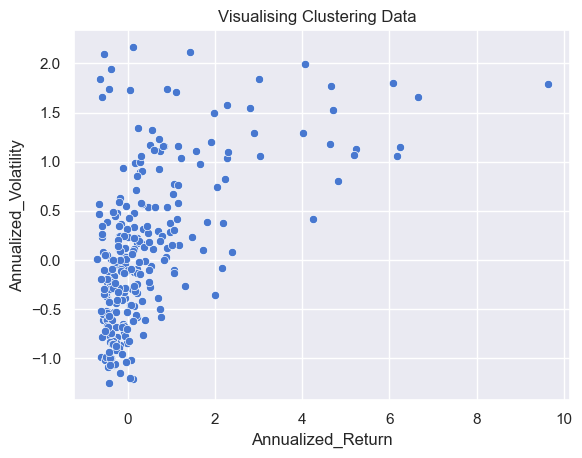

In [9]:
sns.scatterplot(x=dataset_scaled[:, 0], y=dataset_scaled[:, 1])
plt.xlabel('Annualized_Return')	
plt.ylabel('Annualized_Volatility')
plt.title('Visualising Clustering Data  ')
plt.show()


In [10]:
from sklearn.cluster import Birch

birch_clust = Birch()
labels = birch_clust.fit_predict(X)

unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(0): np.int64(253), np.int64(1): np.int64(13), np.int64(2): np.int64(1)}


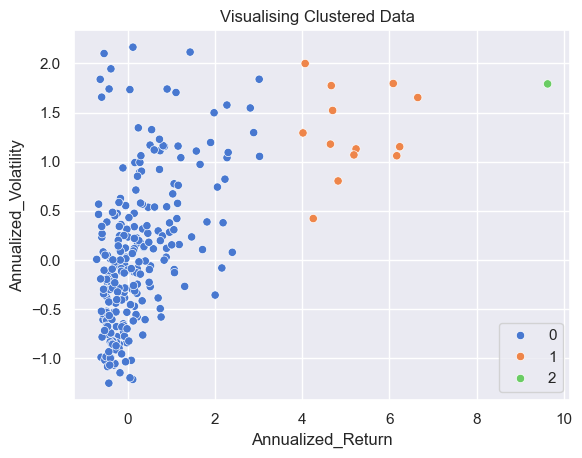

In [11]:
sns.scatterplot(x=dataset_scaled[:, 0], y=dataset_scaled[:, 1], hue=labels, palette='muted')
plt.xlabel('Annualized_Return')	
plt.ylabel('Annualized_Volatility')
plt.title('Visualising Clustered Data  ')
plt.show()


## The clusters are very uneven. So choosing next best algorithm.
## Clustering using Aglomerative based on Silhoutte and DaviesBouldin scores

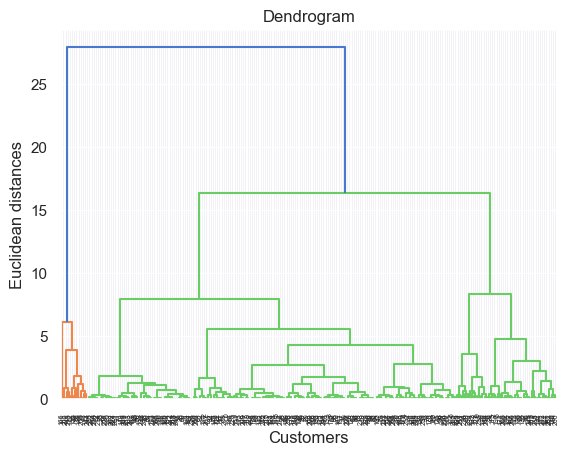

In [12]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()


In [13]:
from sklearn.cluster import AgglomerativeClustering

clusmodel = AgglomerativeClustering(n_clusters = 3)
labels = clusmodel.fit_predict(X)
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(0): np.int64(54), np.int64(1): np.int64(14), np.int64(2): np.int64(199)}


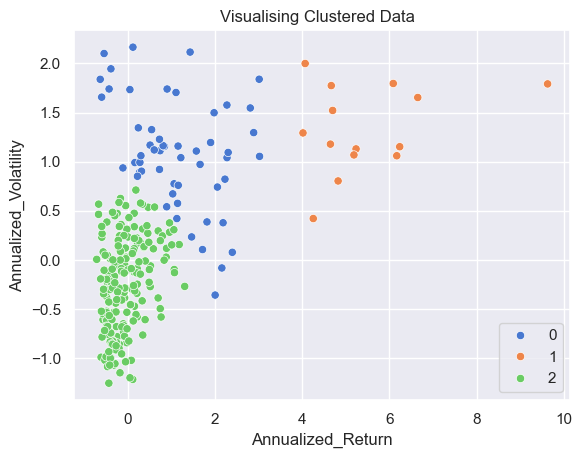

In [14]:
sns.scatterplot(x=dataset_scaled[:, 0], y=dataset_scaled[:, 1], hue=labels, palette='muted')
plt.xlabel('Annualized_Return')	
plt.ylabel('Annualized_Volatility')
plt.title('Visualising Clustered Data  ')
plt.show()


## Understanding what each cluster means

In [20]:
supervised=pd.DataFrame(dataset_clust)
supervised['Clusters']=labels
dataset_reduced['Clusters']=labels

supervised


,Annualized_Return,Annualized_Volatility,Clusters
0,3.524515,0.589975,2
1,-0.517008,0.585279,2
2,2.615783,0.571198,2
3,0.639011,0.573486,2
4,2.476973,0.697101,2
...,...,...,...
262,-0.058463,0.432499,2
263,4.216138,0.828349,0
264,0.777135,0.707369,2
265,14.446618,0.809376,1


In [16]:
# Grouped means for each feature by Cluster_group:
means = supervised.groupby('Clusters').mean()
means


,Annualized_Return,Annualized_Volatility
Clusters,,
0,4.142312,0.811973
1,15.127465,0.864809
2,1.139920,0.531793


|Cluster  |  Name                 |  Description                         | 
|:--------:|:--------------------:|:-------------------------------------:|
|0        |  Balanced Stocks      |  Moderate return and volatility      | 
|1        |  Aggressive Stocks    |  High return, high volatility  |
|2        |  Conservative Stocks  |  Low return, low volatility |

In [21]:

dataset_reduced['Categories'] = dataset_reduced['Clusters'].map({0:'Balanced', 1:'Aggressive', 2:'Conservative'})


In [22]:
filename='supervised.pkl'
pickle.dump(supervised, open(filename,'wb'))
filename='full_dataset.pkl'
pickle.dump(dataset_reduced, open(filename,'wb'))
